# Week 4: Transfer Learning, BERT (Seminar)

### Using pretrained transformers (for fun, profit and 1 point)

There are many toolkits that let you access pretrained transformer models (like we used pretrained embeddings earlier), but the most powerful and convenient by far is 🤗[`huggingface/transformers`](https://github.com/huggingface/transformers). In this week's practice, you'll learn how to download, apply and modify pretrained transformers for a range of tasks. Buckle up, we're going in!


__Pipelines:__ if all you want is to apply a pretrained model, you can do that in one line of code using pipeline. Huggingface/transformers has a selection of pre-configured pipelines for masked language modelling, sentiment classification, question aswering, etc. ([see full list here](https://huggingface.co/transformers/main_classes/pipelines.html))

A typical pipeline includes:
* pre-processing, e.g. tokenization, subword segmentation
* a backbone model, e.g. bert finetuned for classification
* output post-processing

Let's see it in action:

In [7]:
!pip install tf-keras


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# dùng phiên bản keras cũ
# Code của bạn ở bên dưới...
import transformers

In [ ]:
sentiment_clf = transformers.pipeline(
    task="sentiment-analysis", # xác định task cho model được chọn
    model="distilbert-base-uncased-finetuned-sst-2-english",
    framework="pt"  # <-- Thêm dòng này để ép dùng PyTorch
)

# distilbert: Đây là một phiên bản "rút gọn" (distilled) của mô hình ngôn ngữ nổi tiếng BERT. Nó chạy nhanh hơn, nhẹ hơn nhưng vẫn giữ được độ chính xác rất cao.
# uncased: Mô hình này đã chuyển toàn bộ chữ cái thành chữ thường trước khi học (ví dụ: "Hello" và "hello" được xem là như nhau).
# finetuned-sst-2: Mô hình đã được huấn luyện tăng cường (fine-tune) trên tập dữ liệu SST-2 (Stanford Sentiment Treebank). Đây là bộ dữ liệu chuẩn chuyên dùng để dạy AI phân loại sắc thái câu thành 2 loại: Tích cực và Tiêu cực.
# english: Mô hình này chỉ hiểu và phân tích tốt nhất ngôn ngữ tiếng Anh.

# truyền vào 2 câu để test score
sentiment_clf(["transformers library can be really useful!", "YSDA midterm is soon"])

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9959487915039062},
 {'label': 'NEGATIVE', 'score': 0.986364483833313}]

In [4]:
transformers.pipelines.SUPPORTED_TASKS.keys()

dict_keys(['audio-classification', 'automatic-speech-recognition', 'feature-extraction', 'text-classification', 'token-classification', 'question-answering', 'table-question-answering', 'visual-question-answering', 'document-question-answering', 'fill-mask', 'summarization', 'translation', 'text2text-generation', 'text-generation', 'zero-shot-classification', 'zero-shot-image-classification', 'conversational', 'image-classification', 'image-segmentation', 'image-to-text', 'object-detection', 'zero-shot-object-detection', 'depth-estimation'])

But how can we find out which model is suitable for chosen task in such a big models space?

Option 1: Using search and filters in [web](https://huggingface.co/models) (user-friendly)

Option 2: Using `huggingface_hub` library to access API from Python (if you want to automate some process)


In [2]:
import huggingface_hub

In [ ]:
some_model = next(huggingface_hub.list_models()) # bên trong là 1 generator hay iterator - bộ lặp). Bạn có thể tưởng tượng nó giống như một cỗ máy phát số thứ tự: bên trong máy có rất nhiều số, nhưng máy chưa đưa cho bạn số nào cả cho đến khi bạn bấm nút yêu cầu.
# Hàm next(iterator) Nó có tác dụng kéo ra phần tử tiếp theo từ bộ lặp.
some_model

ModelInfo(id='zai-org/GLM-5.2', author=None, sha=None, created_at=datetime.datetime(2026, 6, 16, 7, 39, 20, tzinfo=datetime.timezone.utc), last_modified=None, private=False, disabled=None, downloads=33589, downloads_all_time=None, gated=None, gguf=None, inference=None, inference_provider_mapping=None, likes=2058, library_name='transformers', tags=['transformers', 'safetensors', 'glm_moe_dsa', 'text-generation', 'conversational', 'en', 'zh', 'arxiv:2602.15763', 'arxiv:2603.12201', 'license:mit', 'eval-results', 'endpoints_compatible', 'region:us'], pipeline_tag='text-generation', mask_token=None, card_data=None, widget_data=None, model_index=None, config=None, transformers_info=None, trending_score=1898, siblings=None, spaces=None, safetensors=None, security_repo_status=None, xet_enabled=None)

In [8]:
filter = (
    "sentiment-analysis",
    "pytorch",
    "vi",
)

filtered_models = huggingface_hub.list_models(
    filter=filter,
    sort="downloads",
    limit=10,
)

print(f"Filtered by {filter}:")
for model in filtered_models:
    print(f"- https://huggingface.co/{model.id} ({model.downloads} downloads, {model.likes} likes)")

Filtered by ('sentiment-analysis', 'pytorch', 'vi'):
- https://huggingface.co/xcixor/sentiment-swahili (5 downloads, 2 likes)
- https://huggingface.co/oxygeneDev/sentiment-multilingual (3 downloads, 0 likes)
- https://huggingface.co/ZycckZ/phobert-base_SA_finetuned (3 downloads, 0 likes)
- https://huggingface.co/mnguyn11/phobert-stock-sentiment-vn30 (0 downloads, 0 likes)


Imagine the situation when you have a long text to read and a lack of time. Luckily, you've got an option to use one of pipelines! But which one?...

**Task 1 (0.5 points)**
- Find a suitable pipeline and model for text below
- Apply model to long text to get a short one
- Pretty-print the result and give an opinion if short text is good or not



In [9]:
import transformers

long_text = """
The widespread adoption of remote work, accelerated by global events in the early 2020s, has triggered a significant and likely permanent shift in how we think about the workplace. This transition away from the traditional central office is having profound and multifaceted effects on urban economies, reshaping everything from commercial real estate to local small businesses.

One of the most immediate and visible impacts has been on the commercial real estate sector. With companies downsizing their physical footprints or adopting fully remote models, demand for office space has plummeted. This has led to rising vacancy rates, downward pressure on commercial rent prices, and a re-evaluation of the financial viability of large office buildings. City governments, which often rely heavily on property taxes from these high-value commercial properties, are now facing substantial budget shortfalls.

Furthermore, the daily rhythm of city centers has changed dramatically. The decline in the number of commuters has had a ripple effect on local businesses that once thrived on their patronage. Lunchtime cafes, after-work bars, dry cleaners, and public transit systems have all experienced a significant drop in revenue. This "doughnut effect" describes a phenomenon where the economic activity hollows out in the city center and increases in suburban residential areas as people work from home and spend their money locally.

However, it's not all negative. This shift also presents new opportunities. Some urban planners see a chance to repurpose vacant office buildings into much-needed residential housing, which could help address housing shortages and revitalize neighborhoods by creating 24/7 communities. Additionally, the ability to work remotely has spurred a reversal of rural depopulation in some regions, as professionals seek a better quality of life outside of major metropolitan areas, potentially distributing economic growth more evenly.

In conclusion, the remote work revolution is fundamentally restructuring urban economies. While it presents serious challenges to established systems like commercial real estate and downtown commerce, it also opens the door to innovative urban renewal and a more geographically dispersed economic landscape. The long-term effects will depend on how effectively cities and businesses can adapt to this new, more flexible paradigm.
"""

# 1. Khởi tạo công cụ tóm tắt. 
# Nếu không chỉ định 'model', Hugging Face sẽ tự động tải mô hình mặc định 
# cho tiếng Anh (thường là sshleifer/distilbart-cnn-12-6 hoặc tương tự).
summarizer = transformers.pipeline("summarization", framework="pt")

# 2. Thực hiện "phép thuật"
# Bạn có thể điều chỉnh độ dài mong muốn của đoạn tóm tắt qua max_length và min_length
# do_sample=False: Yêu cầu AI chọn ra những từ ngữ mang tính logic và chính xác nhất theo xác suất cao nhất (Greedy decoding), thay vì chọn ngẫu nhiên có tính sáng tạo. Đối với tóm tắt văn bản thực tế, mình nên để False để đảm bảo độ bám sát nội dung.
result = summarizer(long_text, max_length=150, min_length=50, do_sample=False)

# 3. Lấy ra kết quả dạng chuỗi (string)
short_text = result[0]['summary_text']

print("--- BẢN TÓM TẮT ---")
print(short_text)

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\models--sshleifer--distilbart-cnn-12-6. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

--- BẢN TÓM TẮT ---
 The widespread adoption of remote work, accelerated by global events in the early 2020s, has triggered a significant and likely permanent shift in how we think about the workplace . This transition away from the traditional central office is having profound and multifaceted effects on urban economies . The decline in commuters has had a ripple effect on local businesses that once thrived on their patronage .


Hugging face model lưu vào ổ C và không tự động xóa cần chạy lệnh: huggingface-cli delete-cache

trong command line 

In [ ]:
# huggingface-cli delete-cache

In [ ]:
# !pip install "huggingface_hub[cli]"

In [ ]:
# hf cache delete

In [22]:
from huggingface_hub import scan_cache_dir

# Quét bộ nhớ đệm
hf_cache_info = scan_cache_dir()

print("Danh sách các mô hình đã tải:\n")
for repo in hf_cache_info.repos:
    print(f"Mô hình: {repo.repo_id}")
    print(f"Kích thước: {repo.size_on_disk_str}")
    
    # Đã sửa lỗi ở đây: Duyệt qua từng revision một cách an toàn
    for revision in repo.revisions:
        print(f"Mã ID (Revision): {revision.commit_hash}")
        
    print("-" * 30)

# LƯU Ý: Để xóa một mô hình, bạn copy dãy mã ID dài ngoằng in ra ở trên
# Thay thế vào chữ 'ĐIỀN_MÃ_ID_VÀO_ĐÂY' và chạy 2 dòng lệnh dưới (bỏ dấu # đi)

# delete_strategy = hf_cache_info.delete_revisions("ĐIỀN_MÃ_ID_VÀO_ĐÂY")
# delete_strategy.execute()

Danh sách các mô hình đã tải:

Mô hình: bert-base-uncased
Kích thước: 441.1M
Mã ID (Revision): 86b5e0934494bd15c9632b12f734a8a67f723594
------------------------------


Code xóa hết mô hình hiện có 

In [ ]:
# !rmdir /s /q "C:\Users\admin\.cache\huggingface\hub"

In [ ]:
# hoặc mỗi lần tải model thì cài đặt ở vị trí khác 

# import os
# os.environ["HF_HOME"] = "E:/HuggingFace_Cache" # Đổi sang đường dẫn ổ D của bạn

In [10]:
assert len(long_text) / len(short_text) > 5, "Too long, didn't read"

One of possible semi-supervised tasks used while BERT training is Masked Language Modeling. So our model have some text prediction capabilities!



In [30]:
mlm_model = transformers.pipeline(
    task="fill-mask",
    model="bert-base-cased",
    framework="pt" 
)

mlm_model("My name is [MASK] Shady!")

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForMaskedLM: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[{'score': 0.09115684777498245,
  'token': 22191,
  'token_str': 'Slim',
  'sequence': 'My name is Slim Shady!'},
 {'score': 0.025677712634205818,
  'token': 2791,
  'token_str': 'Captain',
  'sequence': 'My name is Captain Shady!'},
 {'score': 0.02322400175035,
  'token': 3056,
  'token_str': 'Miss',
  'sequence': 'My name is Miss Shady!'},
 {'score': 0.01629176363348961,
  'token': 4479,
  'token_str': 'Jimmy',
  'sequence': 'My name is Jimmy Shady!'},
 {'score': 0.013304662890732288,
  'token': 13960,
  'token_str': 'Mister',
  'sequence': 'My name is Mister Shady!'}]

fill-mask (hay chính xác hơn là Masked Language Modeling - MLM) là bài toán yêu cầu mô hình AI dự đoán một từ bị che khuất (đại diện bằng ký hiệu [MASK]) bên trong một câu.

Thay vì chỉ đọc văn bản từ trái sang phải, các mô hình như BERT sẽ đọc ngữ cảnh từ cả hai phía (trước và sau từ bị che) để suy luận ra từ vựng phù hợp nhất. Đây chính là cách AI tự học cấu trúc ngữ pháp và ý nghĩa của ngôn ngữ.

Kết quả trả về là một danh sách các dự đoán (predictions) tốt nhất của AI, được sắp xếp theo độ tự tin từ cao xuống thấp. Lấy ví dụ kết quả top 1 của bạn:

score (0.0911...): Độ tự tin (xác suất) của AI. Ở đây, mô hình tự tin khoảng 9.1% rằng từ bị thiếu là "Slim".

token_str ('Slim'): Từ mà AI quyết định điền vào chỗ trống. Điểm thú vị là mô hình đã học được văn hóa đại chúng (pop culture) từ dữ liệu huấn luyện khổng lồ trên Internet và nhận ra cụm từ nổi tiếng "My name is Slim Shady" của rapper Eminem.

token (22191): Mã định danh (ID) của chữ 'Slim' trong bộ từ điển (vocabulary) của mô hình bert-base-cased. AI không hiểu chữ cái như con người, nó quản lý các từ bằng các con số này.

sequence: Câu hoàn chỉnh sau khi đã lắp từ dự đoán vào. Các kết quả tiếp theo ('Captain', 'Miss', 'Jimmy'...) là những phương án dự phòng hợp lý về mặt ngữ pháp (Tên của tôi là [Danh xưng/Tên riêng] Shady).

In order to make result more readable we can just take top-1 result:

In [31]:
mlm_model("My name is [MASK] Shady!")[0]["sequence"]

'My name is Slim Shady!'

**Task 2 (0.5 points)**
- Using BERT's ability to solve MLM task, find out answers on the following questions
- Perform some fact-checking, don't trust LLMs!

**Questions:**
- When YSDA was founded?
- Who invented radio first?
- What is the fifth Fibonacci number?

---

In [37]:
mlm_model("YSDA was founded in [MASK].")

[{'score': 0.01959182508289814,
  'token': 1726,
  'token_str': 'India',
  'sequence': 'YSDA was founded in India.'},
 {'score': 0.01870555616915226,
  'token': 1999,
  'token_str': 'Japan',
  'sequence': 'YSDA was founded in Japan.'},
 {'score': 0.01755046285688877,
  'token': 172,
  'token_str': 'c',
  'sequence': 'YSDA was founded in c.'},
 {'score': 0.012400217354297638,
  'token': 1498,
  'token_str': 'London',
  'sequence': 'YSDA was founded in London.'},
 {'score': 0.011938827112317085,
  'token': 1860,
  'token_str': 'Germany',
  'sequence': 'YSDA was founded in Germany.'}]

In [35]:
mlm_model("YSDA was founded in [MASK].")[0]["sequence"]

'YSDA was founded in India.'

In [38]:
mlm_model("[MASK] invented radio first.")

[{'score': 0.4062461256980896,
  'token': 1124,
  'token_str': 'He',
  'sequence': 'He invented radio first.'},
 {'score': 0.03451235219836235,
  'token': 1153,
  'token_str': 'She',
  'sequence': 'She invented radio first.'},
 {'score': 0.025972776114940643,
  'token': 1220,
  'token_str': 'They',
  'sequence': 'They invented radio first.'},
 {'score': 0.019989946857094765,
  'token': 1119,
  'token_str': 'he',
  'sequence': 'he invented radio first.'},
 {'score': 0.008319265209138393,
  'token': 146,
  'token_str': 'I',
  'sequence': 'I invented radio first.'}]

In [36]:
mlm_model("[MASK] invented radio first.")[0]["sequence"]

'He invented radio first.'

In [39]:
mlm_model("the fifth Fibonacci number is [MASK].")

[{'score': 0.04374365508556366,
  'token': 6756,
  'token_str': 'zero',
  'sequence': 'the fifth Fibonacci number is zero.'},
 {'score': 0.031088419258594513,
  'token': 17852,
  'token_str': 'omitted',
  'sequence': 'the fifth Fibonacci number is omitted.'},
 {'score': 0.0224238820374012,
  'token': 1575,
  'token_str': 'lost',
  'sequence': 'the fifth Fibonacci number is lost.'},
 {'score': 0.02194168046116829,
  'token': 3655,
  'token_str': 'unknown',
  'sequence': 'the fifth Fibonacci number is unknown.'},
 {'score': 0.017108792439103127,
  'token': 1215,
  'token_str': 'used',
  'sequence': 'the fifth Fibonacci number is used.'}]

### The building blocks of a pipeline

Huggingface also allows you to access its pipelines on a lower level. There are two main abstractions for you:
* `Tokenizer` - converts from strings to token ids and back
* `Model` - a PyTorch `nn.Module` with pretrained weights

You can use such models as part of your regular PyTorch code: insert it as a layer in your model, apply to a batch of data, backpropagate, optimize, etc.

In [4]:
import transformers

tokenizer = transformers.AutoTokenizer.from_pretrained("bert-base-uncased")
model = transformers.AutoModel.from_pretrained("bert-base-uncased")

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you e

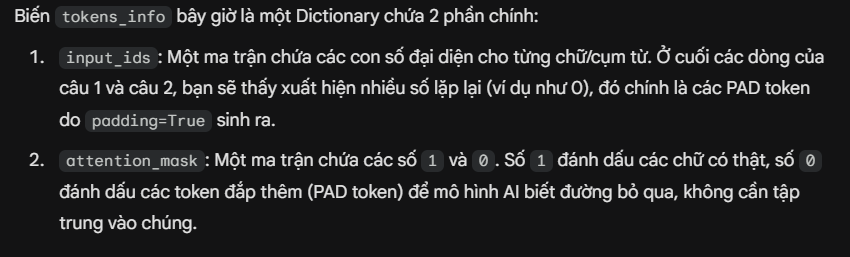

In [5]:
lines = [
    "Luke, I am your father.",
    "Life is what happens when you're busy making other plans.",
    "I have no idea what pneumonoultramicroscopicsilicovolcanoconiosis is."
]
# truncation: câu nào vượt quá size thì cắt bỏ thừa 
# đưa kết quả về pytorch
tokens_info = tokenizer(lines, padding=True, truncation=True, return_tensors="pt")
print("Tokenized:")
print(tokens_info)

print("\nDetokenized:")
for i in range(3):
    print(tokenizer.decode(tokens_info['input_ids'][i])) # Lấy danh sách các số (Token IDs) của từng câu và tra từ điển để ghép lại thành câu chữ.

Tokenized:
{'input_ids': tensor([[  101,  5355,  1010,  1045,  2572,  2115,  2269,  1012,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0],
        [  101,  2166,  2003,  2054,  6433,  2043,  2017,  1005,  2128,  5697,
          2437,  2060,  3488,  1012,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0],
        [  101,  1045,  2031,  2053,  2801,  2054,  1052,  2638,  2819, 17175,
         11314,  6444,  2594,  7352, 26461, 27572, 11261,  6767, 15472,  6761,
          8663, 10735,  2483,  2003,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]]), 'attention_mask': tensor([[1, 1,

You can see some special tokens appeared besides our original text. They are usually used to give model some additional information, so model treats them in individual way.

You can list all special tokens used by tokenizer (moreover, you can add your own special tokens, but make sure you will show them to your model while training):

In [6]:
# tokenizer._special_tokens_map
# Cách đúng để xem từ điển các token đặc biệt
tokenizer.special_tokens_map

{'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]'}

In [7]:
tokenizer("First sentence", "Second sentence", return_token_type_ids=True)
# ngăn cách các câu bằng SEP, 

{'input_ids': [101, 2034, 6251, 102, 2117, 6251, 102], 'token_type_ids': [0, 0, 0, 0, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

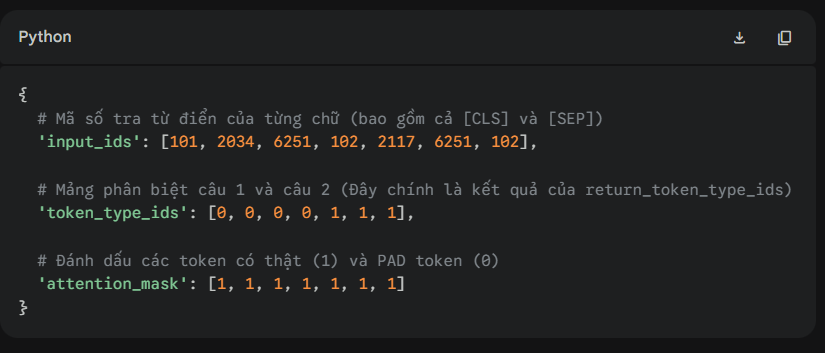

It's ineffective to put all possible tokens in vocabulary, but one also want to handle all possible text sequences instead of putting UNK everywhere.

WordPiece tokenization is here to help!

In [8]:
reversed_vocab = {token_id: token for token, token_id in tokenizer.vocab.items()}

In [9]:
for token_id in tokens_info["input_ids"][2]: # đây là câu 3 phía trên
    print(reversed_vocab[token_id.item()], end=' ') # các từ nối nhau bằng ' ' 

[CLS] i have no idea what p ##ne ##um ##ono ##ult ##ram ##ic ##ros ##copic ##sil ##ico ##vo ##lc ##ano ##con ##ios ##is is . [SEP] 

Từ dài bị phân mảnh thành các sub word con 

Các dấu ## báo hiệu rằng đây là phần đuôi được nối liền vào chữ cái đứng trước nó.

Now you can apply tokenized data with model.

Depending on your task, you can use different part of output. For example, `[CLS]`-token output can be obtained by `pooler_output` key in model output.

In [10]:
import torch

In [11]:
with torch.no_grad():
    out = model(**tokens_info)

print(out['pooler_output'])

tensor([[-0.8854, -0.4722, -0.9392,  ..., -0.8081, -0.6955,  0.8748],
        [-0.9297, -0.5161, -0.9334,  ..., -0.9017, -0.7492,  0.9201],
        [-0.6808, -0.1979, -0.7096,  ..., -0.6691, -0.4557,  0.7595]])


Transformers knowledge hub: https://huggingface.co/transformers/



---



### Visualizing BERT

Interpretability of models is one of key factors of understanding their behaviour.

Neural Networks are harder to interpret than Classic ML models, but still it's not impossible!

Remember Attention mechanism? It's human-understandable concept: look closely to tokens which are more valuable for context of the current one.

In [15]:
!pip install bertviz

   ---------------------------------------- 0.0/15.3 MB ? eta -:--:--
   -------------------- ------------------- 7.9/15.3 MB 44.2 MB/s eta 0:00:01
   ---------------------------------------- 15.3/15.3 MB 48.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 52.8 MB/s  0:00:00

   ------ --------------------------------- 1/6 [jmespath]
   ------ --------------------------------- 1/6 [jmespath]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------- 2/6 [botocore]
   ------------- -------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


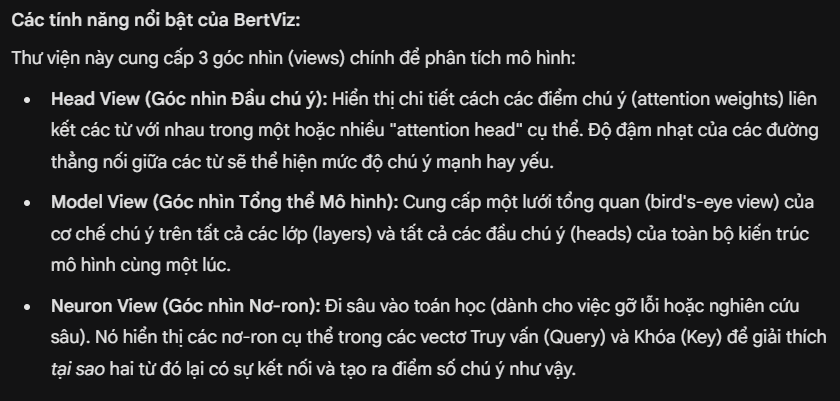

In [12]:
from transformers import AutoTokenizer, AutoModel, utils
from bertviz import model_view, head_view

input_text = "Every time I try to interpret BERT model behaviour, I find new interesting patterns"
model = AutoModel.from_pretrained("bert-base-cased", output_attentions=True)
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

inputs = tokenizer.encode(input_text, return_tensors="pt")
outputs = model(inputs)
attention = outputs[-1]
tokens = tokenizer.convert_ids_to_tokens(inputs[0])

model_view(attention, tokens)

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


<IPython.core.display.Javascript object>

In [17]:
head_view(attention, tokens)

<IPython.core.display.Javascript object>

Another possible task for BERT training is Next Sentence Prediction.

How BERT's heads looks at tokens in that case?

In [13]:
inputs = tokenizer.encode("I'm waiting for important call", "I can't go out right now", return_tensors="pt")
outputs = model(inputs)
attention = outputs[-1]
tokens = tokenizer.convert_ids_to_tokens(inputs[0])

model_view(attention, tokens)

<IPython.core.display.Javascript object>

In [19]:
head_view(attention, tokens)

<IPython.core.display.Javascript object>

Cột bên trái: Là danh sách các token (từ/ký tự) của câu đầu vào. Hãy tưởng tượng đây là từ đang đóng vai trò "người đi tìm kiếm thông tin" (trong thuật toán gọi là Query).

Cột bên phải: Cùng là danh sách các token đó. Đây là các từ đang cung cấp thông tin, hay các từ đang "được chú ý tới" (gọi là Key).

Các đường nối: Biểu diễn điểm số chú ý (attention weight) nối từ một token bên trái sang các token bên phải.

It looks interesting, doesn't it?

If you want to find out more about attention patterns, you can refer to special "field" of science - [BERTology](https://huggingface.co/docs/transformers/main/en/bertology).



---



### Tuning pretrained transfomers (for your own task and 2 points)

Important benefit of using big models is their ability to adapt to various tasks without spending a lot of time and resources for full training.

You could've heard about backbone models in another ML tasks, when they're tuned using specific data.

It's possible to tune model's weights directly, but you also can freeze model, use its outputs as knowledge and then extract neccessary information using much smaller neural networks.

#### Introduction

Here's an example of tuned BERT base model for Named Entity Recognition (NER) task:

In [14]:
tokenizer = transformers.AutoTokenizer.from_pretrained("dslim/bert-base-NER")
model = transformers.AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")

In [15]:
model

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

As you can see, there's an additional classifier besides original BERT content. That layer is used to predict NER-classes for each BERT's token output.

BERT is suitable for tuning for different tasks since it outputs token embeddings and the whole data embedding in `[CLS]`-token as well.

#### Data preparation

In [23]:
!pip install datasets

   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 555.1/555.1 kB 9.4 MB/s  0:00:00
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ----------- ---------------------------- 8.1/27.3 MB 38.7 MB/s eta 0:00:01
   --------------------- ------------------ 14.4/27.3 MB 34.9 MB/s eta 0:00:01
   ----------------------------- ---------- 19.9/27.3 MB 32.3 MB/s eta 0:00:01
   ------------------------------- -------- 21.2/27.3 MB 31.3 MB/s eta 0:00:01
   -------------------------------- ------- 22.3/27.3 MB 21.7 MB/s eta 0:00:01
   -------------------------------------- - 26.0/27.3 MB 20.8 MB/s eta 0:00:01
   ---------------------------------------- 27.3/27.3 MB 20.1 MB/s  0:00:01

   -------- ------------------------------- 1/5 [pyarrow]
   -------- ------------------------------- 1/5 [pyarrow]
   -------- ------------------------------- 1/5 [pyarrow]
   -------- ------------------------------- 1/5 [pyarrow]



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import datasets

In [17]:
dataset = datasets.load_dataset("lhoestq/conll2003")

In [18]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

In [19]:
dataset["train"][0] # đây là cấu trúc 1 sample trong train 

{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

Since BERT tokenization is different from the dataset's one, we need to fix that divergence.

**Task 3 (0.5 points)**
- Align dataset token labels to WordPiece tokens
- Handle special tokens as well

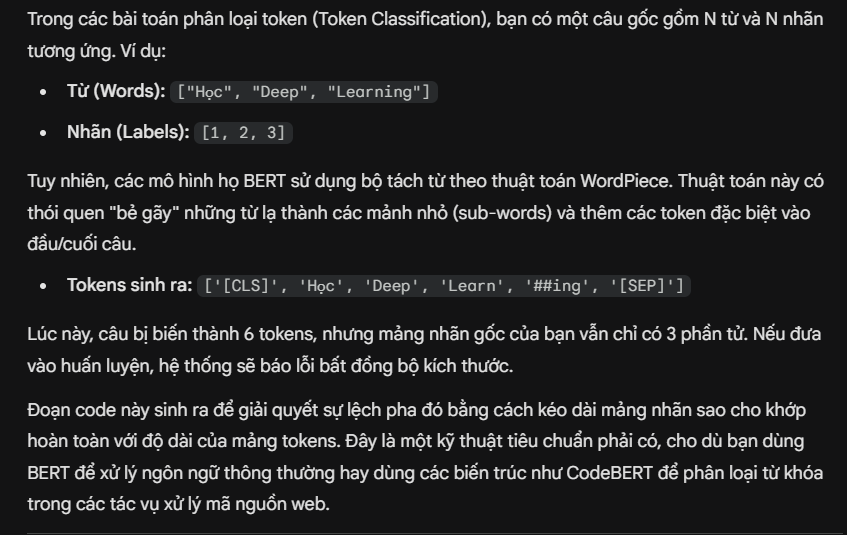

Trong Pytorch, -100 là chỉ số mặc định báo cho hàm tính lỗi (Loss Function) biết là "hãy nhắm mắt làm ngơ, đừng tính toán sai số trên vị trí này".

In [ ]:
from transformers import AutoTokenizer, DataCollatorForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_and_align_labels(samples): # Biến samples là một Dictionary chứa đầu vào của nhiều câu cùng lúc.
    # is_split_into_words=True báo cho tokenizer biết đầu vào đã được tách thành danh sách các từ
    tokenized_inputs = tokenizer(samples["tokens"], truncation=True, is_split_into_words=True)
    # samples["tokens"]: Mảng 2 chiều, Shape: (batch_size, num_words)
    # đi qua tokenize trên thì tự động chèn và chia sub-tokens

    labels = []
    # samples["ner_tags"]: Mảng 2 chiều, Shape: (batch_size, num_words) chứa các vị trí có nertag kèm ids tag
    for i, original_labels in enumerate(samples["ner_tags"]):
        
        # Lấy mảng ánh xạ: token hiện tại thuộc về từ gốc thứ mấy trong câu, không phải là chuyển từ word thành id khâu truyền "input_ids" đã làm vậy rồi 
        # nhưng label chưa được gán lại
        word_ids = tokenized_inputs.word_ids(batch_index=i) # trả về một mảng chỉ ra mỗi token sinh ra thuộc về từ gốc thứ mấy.
        
        previous_word_idx = None # Tạo biến lưu vết để kiểm tra xem khi lặp qua các token, chúng ta đang ở từ cũ hay đã bước sang một từ mới.
        label_ids = [] # Tạo mảng rỗng để chứa bộ nhãn tương ứng cho câu hiện tại.
        
        for word_idx in word_ids: # Vòng lặp gán nhãn cho từng Token
            # Trường hợp 1: Special tokens (như [CLS], [SEP]) sẽ có word_idx là None.
            if word_idx is None:
                label_ids.append(-100)
                
            # Trường hợp 2: Đây là token đầu tiên của một từ.
            elif word_idx != previous_word_idx:
                label_ids.append(original_labels[word_idx])
                
            # Trường hợp 3: Đây là các sub-token tiếp theo của cùng một từ (ví dụ: '##ers').
            else:
                # Gán -100 để bỏ qua khi tính loss, hoặc gán original_labels[word_idx] 
                # tùy thuộc vào chiến lược thiết kế mô hình của bạn. 
                # Thông thường trong PyTorch, chúng ta dùng -100.
                label_ids.append(-100)  # không đọc từ sub mà đọc từ gốc thôi
                
            previous_word_idx = word_idx
            
        labels.append(label_ids) # Gắn bộ nhãn chuẩn chỉnh của câu hiện tại vào mảng labels tổng của toàn bộ batch.

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

In [21]:
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)

In [ ]:
tokenized_dataset["train"][0] # code trên tác động là thêm labels mới ở cuối 

{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0],
 'input_ids': [101,
  7270,
  22961,
  1528,
  1840,
  1106,
  21423,
  1418,
  2495,
  12913,
  119,
  102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [-100, 3, 0, 7, 0, 0, 0, 7, 0, -100, 0, -100]}

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
# khâu này để padding 
# Với input_ids: Nó thêm số 0 (mã của token [PAD]).
# Với labels: Nó thêm số -100 vào cuối mảng nhãn.

Now dataset is ready to be used by BERT.

#### Model preparation

For our task we can use `AutoModelForTokenClassification`, which already provides required architecture with token classifier (e.g. classifier itself, class outputs).

You can handle these things by yourself: create PyTorch model class, init BERT model and Linear layer for classification, then override forward method and so on...

`AutoModelForTokenClassification` is chosen for the sake of simplicity, but it's still required for MLE to be capable of doing it with bare hands.

In [23]:
from transformers import AutoModelForTokenClassification

id2label = {0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG", 5: "B-LOC", 6: "I-LOC", 7: "B-MISC", 8: "I-MISC"}
label2id = {label: id for id, label in id2label.items()}

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=9,
    id2label=id2label,
    label2id=label2id,
)

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForTokenClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['cl

#### Evaluation

Evaluation is crucial while writing papers or reporting your work results. Sometimes it can be tricky and own implementation can be buggy, so it usually preferred to calculate metrics using frameworks.

In [ ]:
!pip install seqeval

Let's prepare `compute_metrics` function for the following training loop:

In [24]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score
from seqeval.scheme import IOB2

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    y_true = []
    y_pred = []
    for i in range(len(predictions)):
        y_true_sample = []
        y_pred_sample = []
        for j in range(len(predictions[i])):
            if labels[i][j] == -100:
                continue

            y_true_sample.append(id2label[int(labels[i][j])])
            y_pred_sample.append(id2label[int(predictions[i][j])])

        y_true.append(y_true_sample)
        y_pred.append(y_pred_sample)

    return {
        "precision": precision_score(y_true, y_pred, mode="strict", scheme=IOB2),
        "recall": recall_score(y_true, y_pred, mode="strict", scheme=IOB2),
        "f1": f1_score(y_true, y_pred, mode="strict", scheme=IOB2),
    }

#### Training

**Task 4 (0.5 points)**
- Choose proper hyperparameters for tuning the model
- Setup HF Trainer
- Check correctness using training results


In [ ]:
# from transformers import TrainingArguments

# training_args = TrainingArguments(
#     output_dir="./bert-ner-dslim-finetuned",
    
#     # Đổi 'eval_strategy' thành 'evaluation_strategy'
#     evaluation_strategy="steps", 
    
#     eval_steps=50,
#     logging_steps=50,
#     logging_dir="./logs",
#     report_to="none",
    
#     learning_rate=1e-5,              
#     num_train_epochs=3,              
#     per_device_train_batch_size=16,  
#     per_device_eval_batch_size=16,
#     weight_decay=0.01,
#     save_strategy="steps",
#     save_steps=50,
#     load_best_model_at_end=True 
# )

In [25]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert-ner-dslim-finetuned",
    
    # 1. CHIẾN LƯỢC ĐÁNH GIÁ VÀ LƯU (Đổi sang epoch cho gọn)
    evaluation_strategy="epoch",  
    save_strategy="epoch",        
    logging_strategy="epoch",     
    
    # 2. GIỚI HẠN DUNG LƯỢNG Ổ CỨNG
    save_total_limit=2,           # Chỉ giữ lại tối đa 2 checkpoint gần nhất, tự xóa cái cũ
    load_best_model_at_end=True,  # Cuối cùng sẽ tự động load lại model có điểm tốt nhất
    
    # 3. TẮT BỚT CẢNH BÁO RÁC TỪ WANDB/MLFLOW
    report_to="none",
    
    # Các thông số học tập giữ nguyên
    learning_rate=1e-5,              
    num_train_epochs=3,              
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,
    weight_decay=0.01,
)

In [27]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"], 
    eval_dataset=tokenized_dataset["validation"], # Có thể là "val" hoặc "test" tùy thuộc vào file dữ liệu gốc của bạn
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Let's check metrics before training:

In [28]:
results = trainer.evaluate(tokenized_dataset["test"])
print(results)

The following columns in the evaluation set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: chunk_tags, id, ner_tags, tokens, pos_tags. If chunk_tags, id, ner_tags, tokens, pos_tags are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 3453
  Batch size = 16
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


  0%|          | 0/216 [00:00<?, ?it/s]

{'eval_loss': 2.2863576412200928, 'eval_precision': 0.014134920924796377, 'eval_recall': 0.06851983002832861, 'eval_f1': 0.023435371060041784, 'eval_runtime': 9.0274, 'eval_samples_per_second': 382.501, 'eval_steps_per_second': 23.927}


In [29]:
trainer.train()

The following columns in the training set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: chunk_tags, id, ner_tags, tokens, pos_tags. If chunk_tags, id, ner_tags, tokens, pos_tags are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 14041
  Num Epochs = 3
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 2634
  Number of trainable parameters = 107726601


  0%|          | 0/2634 [00:00<?, ?it/s]

The following columns in the evaluation set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: chunk_tags, id, ner_tags, tokens, pos_tags. If chunk_tags, id, ner_tags, tokens, pos_tags are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 3250
  Batch size = 16


{'loss': 0.1578, 'learning_rate': 6.666666666666667e-06, 'epoch': 1.0}


  0%|          | 0/204 [00:00<?, ?it/s]

...

Saving model checkpoint to ./bert-ner-dslim-finetuned\checkpoint-2634
Configuration saved in ./bert-ner-dslim-finetuned\checkpoint-2634\config.json


{'eval_loss': 0.04286772385239601, 'eval_precision': 0.9410777236864193, 'eval_recall': 0.9434533826994278, 'eval_f1': 0.9422640558030085, 'eval_runtime': 8.9726, 'eval_samples_per_second': 362.214, 'eval_steps_per_second': 22.736, 'epoch': 3.0}


Model weights saved in ./bert-ner-dslim-finetuned\checkpoint-2634\pytorch_model.bin
Deleting older checkpoint [bert-ner-dslim-finetuned\checkpoint-878] due to args.save_total_limit


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./bert-ner-dslim-finetuned\checkpoint-2634 (score: 0.04286772385239601).


{'train_runtime': 512.694, 'train_samples_per_second': 82.16, 'train_steps_per_second': 5.138, 'train_loss': 0.07400865489638205, 'epoch': 3.0}


TrainOutput(global_step=2634, training_loss=0.07400865489638205, metrics={'train_runtime': 512.694, 'train_samples_per_second': 82.16, 'train_steps_per_second': 5.138, 'train_loss': 0.07400865489638205, 'epoch': 3.0})

In [30]:
results = trainer.evaluate(tokenized_dataset["test"])
print(results)

The following columns in the evaluation set don't have a corresponding argument in `BertForTokenClassification.forward` and have been ignored: chunk_tags, id, ner_tags, tokens, pos_tags. If chunk_tags, id, ner_tags, tokens, pos_tags are not expected by `BertForTokenClassification.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 3453
  Batch size = 16


  0%|          | 0/216 [00:00<?, ?it/s]

{'eval_loss': 0.11104042828083038, 'eval_precision': 0.9063215354815989, 'eval_recall': 0.9112960339943342, 'eval_f1': 0.9088019775757041, 'eval_runtime': 8.431, 'eval_samples_per_second': 409.559, 'eval_steps_per_second': 25.62, 'epoch': 3.0}


Compare test metrics before and after training. Did we succeed?

Yes

**Task 5 (1 point)**
- Compare our model's result with `dslim/bert-base-NER`
- Try to improve our model's quality. Choose any option:
  - Play with training hyperparameters (batch_size, lr, epochs, etc.)
  - Apply some training techniques (warm-up, lr-scheduling, etc.)
  - Perform error analysis and find model's weak spots (this option doesn't require fixing them)
  - Your very own idea
- Write a small report (up to 5 steps, results and conclusions) on the work done in "Tuning pretrained transformers" part